# Sound 03: Liberal vs Conservative — Temporal Trajectory

**Question:** How do the structural differences between liberal and conservative belief networks evolve from 1974 to 2022?

Sound 02 established that the lib/con difference in 2000–2010 is statistically significant (Z=6.81).
Here we track that difference over time using 4-year rolling windows, with sample-size matching
at every window.

**Method:** 4-year windows, 2-year steps, regularized partial Pearson (alpha=0.2), groups
downsampled to match the smaller group's N at each window.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from tqdm.auto import tqdm

from src.loaders.clean_raw_data import clean_datasets
from src.generators.corr_make_network import (
    calculate_correlation_matrix, CorrelationMethod, EdgeSuppressionMethod
)
from src.analyzers.matrix_compare import compare_matrices
from src.visualizers.network_visualizer import calculate_network_stats

C:\Users\timbo\miniconda3\Lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
cleaned_df = clean_datasets()

METHOD = CorrelationMethod.PEARSON
EDGE_SUPP = EdgeSuppressionMethod.REGULARIZATION
SUPP_PARAMS = {'regularization': 0.2}

WINDOW_SIZE = 4  # years
STEP_SIZE = 2    # years

# All years with POLVIEWS data
polviews_years = sorted(cleaned_df[cleaned_df['POLVIEWS'].notna()]['YEAR'].unique())
polviews_years = [int(y) for y in polviews_years]
print(f"POLVIEWS available in {len(polviews_years)} years: {polviews_years[0]}-{polviews_years[-1]}")

# Define window start years
first_year = int(polviews_years[0])
last_year = int(polviews_years[-1])
window_starts = list(range(first_year, last_year - WINDOW_SIZE + 2, STEP_SIZE))
print(f"Rolling windows: {len(window_starts)} windows")
print(f"First window: {window_starts[0]}-{window_starts[0]+WINDOW_SIZE}")
print(f"Last window: {window_starts[-1]}-{window_starts[-1]+WINDOW_SIZE}")

Loading dataset from from cache...


Done! ✨


POLVIEWS available in 32 years: 1974-2022
Rolling windows: 23 windows
First window: 1974-1978
Last window: 2018-2022


## 3.1 Rolling Window Comparison

For each 4-year window:
1. Filter to respondents with non-null, non-zero POLVIEWS
2. Build liberal network (POLVIEWS < 0)
3. Downsample the larger group to match the smaller group's N
4. Build matched conservative network
5. Compute comparison metrics

In [3]:
results = []

for start in tqdm(window_starts, desc='Rolling windows'):
    end = start + WINDOW_SIZE
    window_years = [y for y in polviews_years if start <= y <= end]
    
    if len(window_years) < 3:
        continue
    
    # Filter to window
    df_window = cleaned_df[cleaned_df['YEAR'].isin(window_years)].copy()
    df_pv = df_window[df_window['POLVIEWS'].notna()]
    
    df_lib = df_pv[df_pv['POLVIEWS'] < 0]
    df_con = df_pv[df_pv['POLVIEWS'] > 0]
    
    n_lib = len(df_lib)
    n_con = len(df_con)
    
    if n_lib < 100 or n_con < 100:
        continue
    
    # Downsample conservatives to match
    n_match = min(n_lib, n_con)
    df_lib_matched = df_lib.sample(n=n_match, random_state=42) if n_lib > n_match else df_lib
    df_con_matched = df_con.sample(n=n_match, random_state=42) if n_con > n_match else df_con
    
    try:
        corr_lib = calculate_correlation_matrix(
            df_lib_matched, method=METHOD, partial=True,
            edge_suppression=EDGE_SUPP, suppression_params=SUPP_PARAMS,
            verbose=False
        )
        corr_con = calculate_correlation_matrix(
            df_con_matched, method=METHOD, partial=True,
            edge_suppression=EDGE_SUPP, suppression_params=SUPP_PARAMS,
            verbose=False
        )
    except Exception as e:
        print(f"  Window {start}-{end}: FAILED ({e})")
        continue
    
    # Comparison metrics
    comp = compare_matrices(corr_lib, corr_con)
    
    # Community detection
    def count_communities(corr_matrix):
        mat = corr_matrix.copy()
        np.fill_diagonal(mat.values, 0)
        G = nx.from_pandas_adjacency(mat.abs())
        G.remove_edges_from([(u, v) for u, v, d in G.edges(data=True) if d['weight'] == 0])
        if G.number_of_nodes() == 0:
            return 0
        comms = nx.community.louvain_communities(G, weight='weight', seed=42)
        # Count communities with 3+ members
        return sum(1 for c in comms if len(c) >= 3)
    
    results.append({
        'window_start': start,
        'window_end': end,
        'window_mid': start + WINDOW_SIZE / 2,
        'n_years': len(window_years),
        'n_matched': n_match,
        'n_lib_total': n_lib,
        'n_con_total': n_con,
        'lib_vars': corr_lib.shape[0],
        'con_vars': corr_con.shape[0],
        'common_vars': len(set(corr_lib.columns) & set(corr_con.columns)),
        'lib_edges': comp['num_edges']['matrix1'],
        'con_edges': comp['num_edges']['matrix2'],
        'lib_density': comp['density']['matrix1'],
        'con_density': comp['density']['matrix2'],
        'lib_avg_degree': comp['avg_degree']['matrix1'],
        'con_avg_degree': comp['avg_degree']['matrix2'],
        'lib_clustering': comp['clustering_coefficient']['matrix1'],
        'con_clustering': comp['clustering_coefficient']['matrix2'],
        'lib_triangles': comp['calc_num_triangles']['matrix1'],
        'con_triangles': comp['calc_num_triangles']['matrix2'],
        'euclidean_distance': comp['euclidean_distance'],
        'pearson_r': comp['pearson_correlation'],
        'lib_communities': count_communities(corr_lib),
        'con_communities': count_communities(corr_con),
    })

df_results = pd.DataFrame(results)
print(f"\nCompleted {len(df_results)} windows")
print(df_results[['window_start', 'window_end', 'n_matched', 'lib_edges', 'con_edges', 'euclidean_distance']].to_string(index=False))

Rolling windows:   0%|          | 0/23 [00:00<?, ?it/s]


Completed 22 windows
 window_start  window_end  n_matched  lib_edges  con_edges  euclidean_distance
         1974        1978       2080        273        218            0.724262
         1976        1980       1594        275        219            0.619841
         1978        1982       1284        296        234            0.770247
         1980        1984       1399        319        256            0.830748
         1982        1986       1736        367        302            0.906403
         1984        1988       1947        379        325            0.910440
         1986        1990       2004        386        306            0.826138
         1988        1992       1569        370        306            0.854896
         1990        1994       1951        371        303            1.090900
         1992        1996       1886        336        318            0.958954
         1994        1998       2245        326        293            1.016300
         1996        2000     

## 3.2 Trajectory Plots

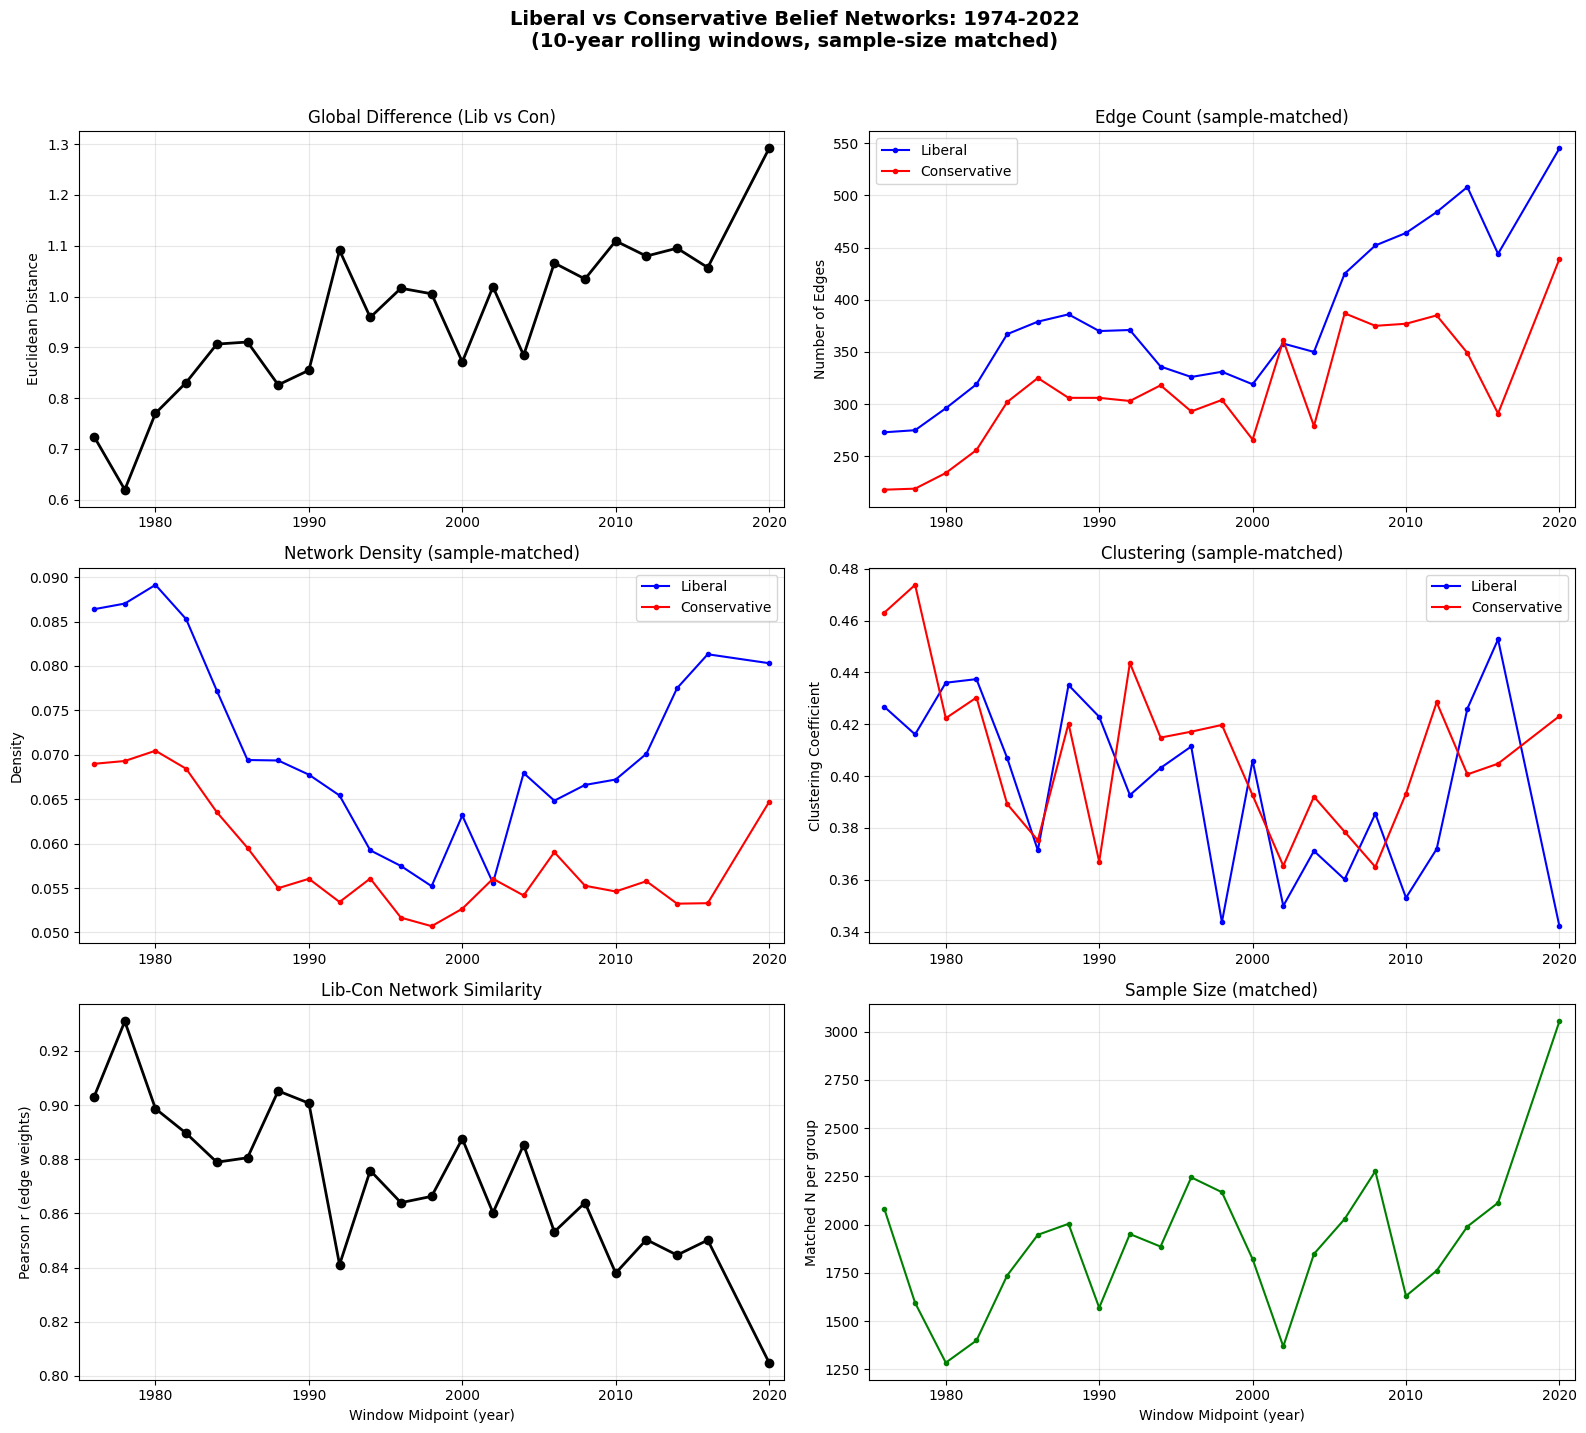

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
mid = df_results['window_mid']

# 1. Euclidean distance between lib/con networks
ax = axes[0, 0]
ax.plot(mid, df_results['euclidean_distance'], 'ko-', linewidth=2)
ax.set_ylabel('Euclidean Distance')
ax.set_title('Global Difference (Lib vs Con)')
ax.grid(True, alpha=0.3)

# 2. Edge count
ax = axes[0, 1]
ax.plot(mid, df_results['lib_edges'], 'b.-', label='Liberal', linewidth=1.5)
ax.plot(mid, df_results['con_edges'], 'r.-', label='Conservative', linewidth=1.5)
ax.set_ylabel('Number of Edges')
ax.set_title('Edge Count (sample-matched)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Density
ax = axes[1, 0]
ax.plot(mid, df_results['lib_density'], 'b.-', label='Liberal', linewidth=1.5)
ax.plot(mid, df_results['con_density'], 'r.-', label='Conservative', linewidth=1.5)
ax.set_ylabel('Density')
ax.set_title('Network Density (sample-matched)')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Clustering
ax = axes[1, 1]
ax.plot(mid, df_results['lib_clustering'], 'b.-', label='Liberal', linewidth=1.5)
ax.plot(mid, df_results['con_clustering'], 'r.-', label='Conservative', linewidth=1.5)
ax.set_ylabel('Clustering Coefficient')
ax.set_title('Clustering (sample-matched)')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Pearson correlation between networks
ax = axes[2, 0]
ax.plot(mid, df_results['pearson_r'], 'ko-', linewidth=2)
ax.set_ylabel('Pearson r (edge weights)')
ax.set_title('Lib-Con Network Similarity')
ax.set_xlabel('Window Midpoint (year)')
ax.grid(True, alpha=0.3)

# 6. Sample size
ax = axes[2, 1]
ax.plot(mid, df_results['n_matched'], 'g.-', linewidth=1.5)
ax.set_ylabel('Matched N per group')
ax.set_title('Sample Size (matched)')
ax.set_xlabel('Window Midpoint (year)')
ax.grid(True, alpha=0.3)

for row_axes in axes:
    for ax in row_axes:
        ax.set_xlim(mid.min() - 1, mid.max() + 1)

plt.suptitle('Liberal vs Conservative Belief Networks: 1974-2022\n(10-year rolling windows, sample-size matched)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

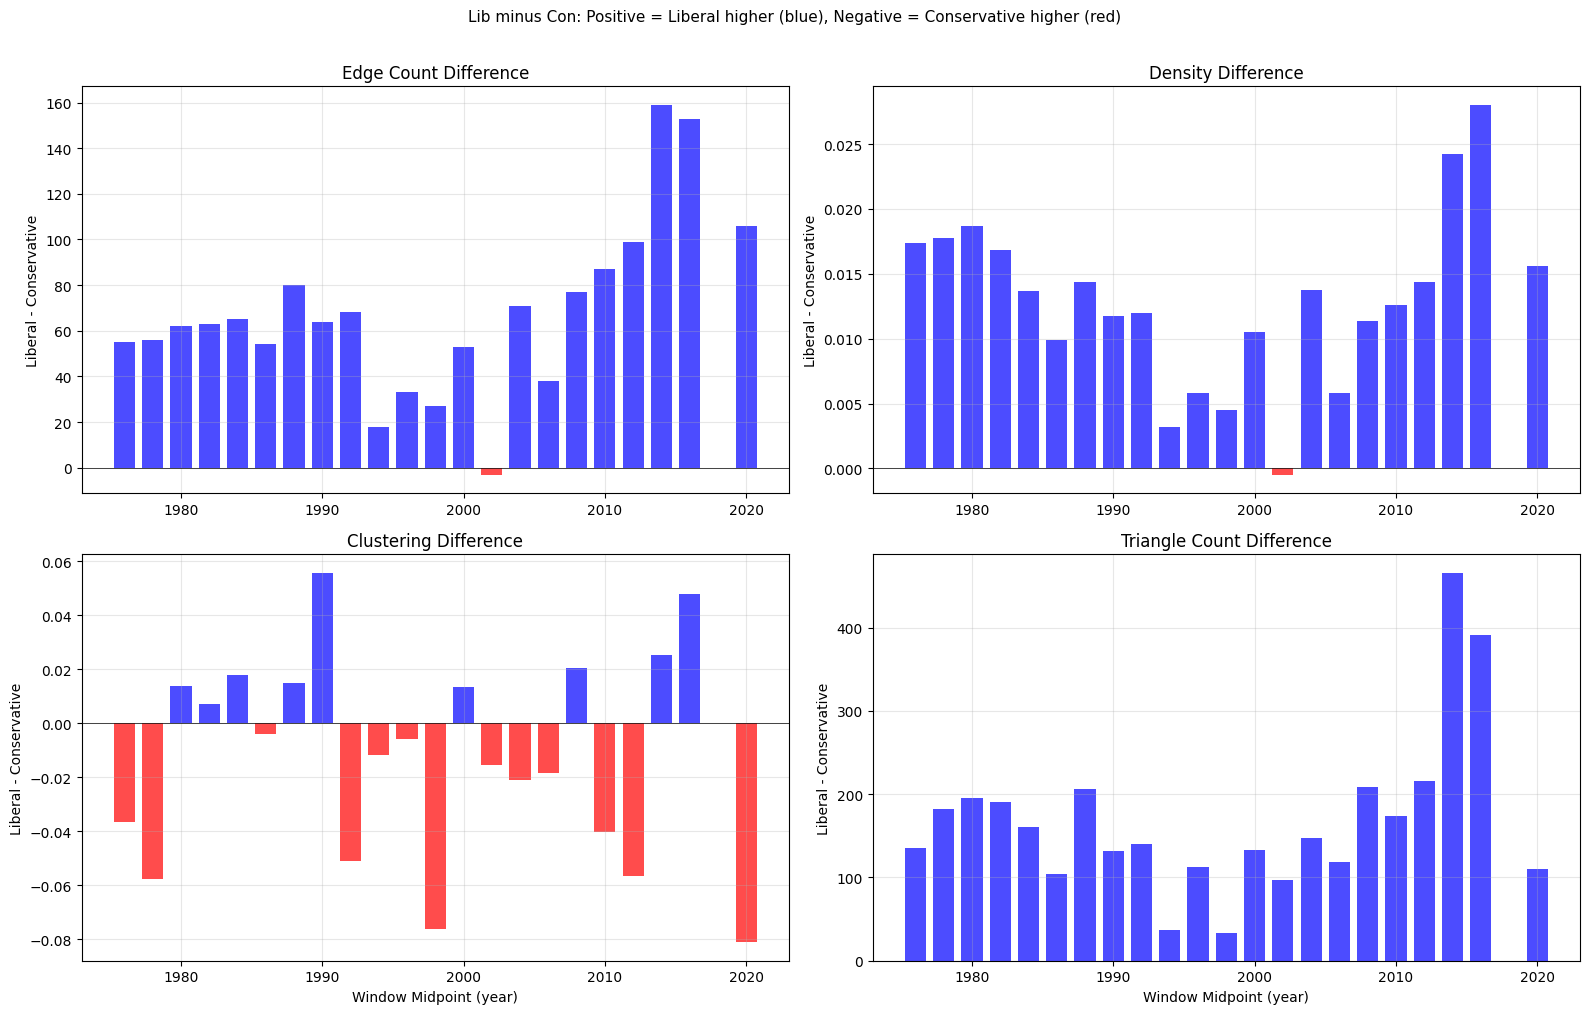

In [5]:
# Derived metrics: lib-con differences over time
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Edge count difference (lib - con)
ax = axes[0, 0]
edge_diff = df_results['lib_edges'] - df_results['con_edges']
ax.bar(mid, edge_diff, width=1.5, color=['blue' if d > 0 else 'red' for d in edge_diff], alpha=0.7)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Liberal - Conservative')
ax.set_title('Edge Count Difference')
ax.grid(True, alpha=0.3)

# Density difference
ax = axes[0, 1]
density_diff = df_results['lib_density'] - df_results['con_density']
ax.bar(mid, density_diff, width=1.5, color=['blue' if d > 0 else 'red' for d in density_diff], alpha=0.7)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Liberal - Conservative')
ax.set_title('Density Difference')
ax.grid(True, alpha=0.3)

# Clustering difference
ax = axes[1, 0]
clust_diff = df_results['lib_clustering'] - df_results['con_clustering']
ax.bar(mid, clust_diff, width=1.5, color=['blue' if d > 0 else 'red' for d in clust_diff], alpha=0.7)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Liberal - Conservative')
ax.set_title('Clustering Difference')
ax.set_xlabel('Window Midpoint (year)')
ax.grid(True, alpha=0.3)

# Triangle count difference
ax = axes[1, 1]
tri_diff = df_results['lib_triangles'] - df_results['con_triangles']
ax.bar(mid, tri_diff, width=1.5, color=['blue' if d > 0 else 'red' for d in tri_diff], alpha=0.7)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Liberal - Conservative')
ax.set_title('Triangle Count Difference')
ax.set_xlabel('Window Midpoint (year)')
ax.grid(True, alpha=0.3)

plt.suptitle('Lib minus Con: Positive = Liberal higher (blue), Negative = Conservative higher (red)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 3.3 Summary Table

In [6]:
# Print full results table
display_cols = [
    'window_start', 'window_end', 'n_matched',
    'lib_edges', 'con_edges',
    'lib_density', 'con_density',
    'lib_clustering', 'con_clustering',
    'euclidean_distance', 'pearson_r'
]

print("=== Full Results Table ===")
print(df_results[display_cols].to_string(index=False, float_format='%.4f'))

print("\n=== Trend Summary ===")
# Early vs late comparison
n_windows = len(df_results)
first_third = df_results.head(n_windows // 3)
last_third = df_results.tail(n_windows // 3)

print(f"\nEarly windows (mid ~{first_third['window_mid'].mean():.0f}):")
print(f"  Euclidean distance: {first_third['euclidean_distance'].mean():.3f}")
print(f"  Lib edges: {first_third['lib_edges'].mean():.0f}, Con edges: {first_third['con_edges'].mean():.0f}")
print(f"  Lib density: {first_third['lib_density'].mean():.4f}, Con density: {first_third['con_density'].mean():.4f}")
print(f"  Lib clustering: {first_third['lib_clustering'].mean():.3f}, Con clustering: {first_third['con_clustering'].mean():.3f}")

print(f"\nLate windows (mid ~{last_third['window_mid'].mean():.0f}):")
print(f"  Euclidean distance: {last_third['euclidean_distance'].mean():.3f}")
print(f"  Lib edges: {last_third['lib_edges'].mean():.0f}, Con edges: {last_third['con_edges'].mean():.0f}")
print(f"  Lib density: {last_third['lib_density'].mean():.4f}, Con density: {last_third['con_density'].mean():.4f}")
print(f"  Lib clustering: {last_third['lib_clustering'].mean():.3f}, Con clustering: {last_third['con_clustering'].mean():.3f}")

# Is the difference growing?
from scipy import stats as sp_stats
slope, intercept, r_val, p_val, std_err = sp_stats.linregress(df_results['window_mid'], df_results['euclidean_distance'])
print(f"\nEuclidean distance trend: slope={slope:.4f}/year, r={r_val:.3f}, p={p_val:.4f}")
if p_val < 0.05:
    if slope > 0:
        print("=> Lib/con networks are DIVERGING over time.")
    else:
        print("=> Lib/con networks are CONVERGING over time.")
else:
    print("=> No significant trend in lib/con divergence.")

=== Full Results Table ===
 window_start  window_end  n_matched  lib_edges  con_edges  lib_density  con_density  lib_clustering  con_clustering  euclidean_distance  pearson_r
         1974        1978       2080        273        218       0.0864       0.0690          0.4267          0.4631              0.7243     0.9031
         1976        1980       1594        275        219       0.0870       0.0693          0.4161          0.4738              0.6198     0.9309
         1978        1982       1284        296        234       0.0891       0.0705          0.4360          0.4223              0.7702     0.8987
         1980        1984       1399        319        256       0.0853       0.0684          0.4374          0.4303              0.8307     0.8896
         1982        1986       1736        367        302       0.0772       0.0635          0.4070          0.3892              0.9064     0.8789
         1984        1988       1947        379        325       0.0694       0.0595 

## Summary

See `analyses/2026-02_sound-lib-con-temporal.md` for the full writeup.